<hr style='border-top:4px solid #1F77B4;'>

<h2><span style="color: #1F77B4; font-size: 35px">Chapitre 15</span></h2>
<h1><span style="color: #1F77B4; font-size: 50px">Programmation dynamique et méthodes de Monte-Carlo</span></h1>

Ce carnet reprend, dans l'ordre du chapitre, l'ensemble des extraits de code présentés dans le texte et permet de régénérer les figures associées selon les conventions graphiques du livre. Il couvre le compromis exploration-exploitation, l'évaluation itérative d'une politique, l'itération sur les politiques et sur les valeurs, ainsi que les méthodes de Monte-Carlo sur politique, à départs exploratoires et hors politique. Deux environnements sont implémentés de bout en bout : un bandit à <i>k</i> bras et un monde en grille de trois lignes sur quatre colonnes, qui sert de fil conducteur au chapitre et sera repris au chapitre 16. Les cellules doivent être exécutées séquentiellement, car certaines réutilisent des variables ou des résultats définis en amont.

**Bibliothèques requises** : `numpy` et `matplotlib`. Aucune bibliothèque d'apprentissage par renforcement n'est utilisée : les deux environnements sont implémentés directement afin de rendre visible la dynamique dont dépendent les algorithmes du chapitre.  
**Données externes** : aucun fichier externe n'est nécessaire.  
**Exécution** : les versions utilisées sont affichées par la cellule de configuration.

<hr style='border-top:4px solid #1F77B4;'>

In [1]:
# Configuration générale : bibliothèques, versions et affichage
import sys
from importlib.metadata import version as package_version

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

PAQUETS = ('numpy', 'matplotlib')

print(f"{'python':<18} {sys.version.split()[0]}")
for paquet in PAQUETS:
    print(f"{paquet:<18} {package_version(paquet)}")

plt.rcParams.update({
    'font.size': 13,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'mathtext.fontset': 'cm',
    'text.usetex': False,
})

# Couleurs du livre (palette viridis)
VIOLET, SARCELLE, VERT = '#482878', '#21918c', '#5ec962'
BLEU    = '#3b528b'
MAGENTA = '#bf00bf'
BORD = {VIOLET: '#2e1a4d', SARCELLE: '#14615d', VERT: '#3a7d3f', BLEU: '#2c3e6b'}
PALETTE = [VIOLET, SARCELLE, VERT, BLEU, MAGENTA]

FLECHE = {'haut': '↑', 'bas': '↓', 'gauche': '←', 'droite': '→'}
FLECHE_GRANDE = {'haut': '⬆', 'bas': '⬇', 'gauche': '⬅', 'droite': '➡'}

python             3.12.13
numpy              2.5.1
matplotlib         3.11.0


<hr style='border-top:4px solid #1F77B4;'>

In [2]:
# Fonction utilitaire de sauvegarde des figures (PDF)
import os

def save_figure(fig, path):
    directory = os.path.dirname(path)
    if directory:
        os.makedirs(directory, exist_ok=True)
    fig.savefig(f"{path}.pdf", format="pdf", bbox_inches='tight')

In [3]:
def dessiner_grille(ax, env, valeurs=None, politique=None, titre='', taille=20):
    """Trace la grille, avec ses valeurs et ses flèches de politique."""
    from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle

    murs = getattr(env, 'mur', set())
    falaise = getattr(env, 'falaise', set())
    n, m = env.n_lignes, env.n_colonnes
    compact = bool(falaise)
    haut = n + (0.55 if titre else 0.05)
    bas = -0.42 if compact else -0.05
    ax.set_xlim(-0.05, m + 0.05)
    ax.set_ylim(bas, haut)
    ax.set_aspect('equal')
    ax.set_axis_off()

    # Tailles adaptées à l'espace physique disponible dans chaque sous-figure.
    pos = ax.get_position()
    largeur, hauteur = ax.figure.get_size_inches()
    unite = 72 * min(largeur * pos.width / (m + 0.1),
                     hauteur * pos.height / (haut - bas))
    corps = min(14, 0.25 * unite)
    petit = min(12, 0.29 * unite)
    en_tete = min(14, 0.28 * unite)

    if titre:
        ax.add_patch(FancyBboxPatch(
            (0, n + 0.12), m, 0.38,
            boxstyle='round,pad=0,rounding_size=0.04',
            facecolor='#F0F1F3', edgecolor='none'))
        ax.add_patch(Rectangle((0, n + 0.12), m, 0.025, facecolor='#3B528B', edgecolor='none'))
        ax.text(m / 2, n + 0.31, titre, ha='center', va='center',
                fontsize=en_tete, color='#172033')

    for i in range(n):
        for j in range(m):
            s, y = (i, j), n - 1 - i
            fond, bord, texte = '#FFFFFF', '#BCC7D8', '#172033'
            if s == env.depart:
                fond, bord, texte = '#E8EFFA', '#3B528B', '#3B528B'
            if s in murs:
                fond, bord, texte = '#D7DBE1', '#9098A6', '#495464'
            elif s in falaise:
                fond, bord, texte = '#D5CBE4', '#414487', '#414487'
            elif s in env.terminaux:
                if env.terminaux[s] < 0:
                    fond, bord, texte = '#D5CBE4', '#414487', '#414487'
                else:
                    fond, bord, texte = '#DEF2E0', '#5EC962', '#315F34'
            ax.add_patch(FancyBboxPatch(
                (j + 0.032, y + 0.032), 0.936, 0.936,
                boxstyle='round,pad=0,rounding_size=0.065',
                facecolor=fond, edgecolor=bord, linewidth=0.9,
                hatch='///' if s in falaise else None))

            if s in murs:
                ax.text(j + 0.5, y + 0.5, 'Mur', ha='center',
                        va='center', fontsize=petit, color=texte)
            elif s in falaise:
                continue
            elif s in env.terminaux:
                if compact:
                    ax.text(j + 0.5, y + 0.5, 'B', ha='center',
                            va='center', fontsize=petit, color=texte)
                else:
                    recompense = env.terminaux[s]
                    ax.text(j + 0.5, y + 0.61, f'${recompense:+.0f}$',
                            ha='center', va='center', fontsize=corps + 2,
                            color=texte)
                    ax.text(j + 0.5, y + 0.26,
                            'Piège' if recompense < 0 else 'But',
                            ha='center', va='center', fontsize=petit,
                            color=texte)
            else:
                if valeurs is not None:
                    ax.text(j + 0.5, y + (0.72 if politique else 0.55),
                            f'${valeurs[s]:+.3f}$', ha='center', va='center',
                            fontsize=corps, color=texte)
                if politique is not None:
                    di, dj = env.PAS[politique[s]]
                    dx, dy = dj, -di
                    cy = y + (0.40 if valeurs is not None else
                              0.56 if s == env.depart else 0.5)
                    ax.add_patch(FancyArrowPatch(
                        (j + 0.5 - 0.20 * dx, cy - 0.20 * dy),
                        (j + 0.5 + 0.20 * dx, cy + 0.20 * dy),
                        arrowstyle='-|>', color='#3B528B',
                        linewidth=1.35, mutation_scale=min(taille, 0.34 * unite),
                        shrinkA=0, shrinkB=0))
                if s == env.depart:
                    ax.text(j + 0.5, y + (0.5 if compact and politique is None
                                         and valeurs is None else 0.15),
                            'D' if compact else 'départ', ha='center',
                            va='center', fontsize=petit, color=texte)
    if compact:
        ax.text(m / 2, -0.23,
                'D : départ   ·   B : but   ·   Hachures : falaise (−100)',
                ha='center', va='center', fontsize=min(9, 0.29 * unite),
                color='#495464')


<hr style='border-top:4px solid #1F77B4;'>

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 15.1 : Le bandit à <i>k</i> bras</h3>

In [4]:
class BanditKBras:
    """k leviers, récompense gaussienne de moyenne q⁎(a) et d'écart-type 1."""

    def __init__(self, k=10, rng=None):
        self.k = k
        self.rng = rng if rng is not None else np.random.default_rng()
        self.q_vrai = self.rng.normal(0.0, 1.0, k)
        self.meilleur = int(np.argmax(self.q_vrai))

    def tirer(self, a):
        return self.rng.normal(self.q_vrai[a], 1.0)

rng = np.random.default_rng(42)
bandit = BanditKBras(10, rng)

# --- Affichage ---
largeur = 7
L = 10 + largeur * bandit.k

print("=" * L)
print("Valeurs vraies par levier")
print("=" * L)
print(f"{'Levier a':<9}:" + "".join(f"{a:>{largeur}}" for a in range(bandit.k)))
print(f"{'q⁎(a)':<9}:" + "".join(f"{q:>{largeur}.2f}" for q in bandit.q_vrai))
print("=" * L)
a_opt = bandit.meilleur
print(f"Levier optimal : {a_opt}  |  q⁎({a_opt}) = {bandit.q_vrai[a_opt]:.2f}")

Valeurs vraies par levier
Levier a :      0      1      2      3      4      5      6      7      8      9
q⁎(a)    :   0.30  -1.04   0.75   0.94  -1.95  -1.30   0.13  -0.32  -0.02  -0.85
Levier optimal : 3  |  q⁎(3) = 0.94


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 15.2 : Compromis exploration-exploitation par une politique $\varepsilon$-gloutonne</h3>

In [5]:
def experience_bandit(epsilon, n_essais=300, n_pas=1000, k=10, graine=42):
    """Moyenne, sur n_essais bandits, de la récompense et du taux d'action optimale."""
    rng = np.random.default_rng(graine)
    recompenses = np.zeros((n_essais, n_pas))
    optimales = np.zeros((n_essais, n_pas))
    for e in range(n_essais):
        bandit = BanditKBras(k, rng)
        Q, N = np.zeros(k), np.zeros(k)
        for t in range(n_pas):
            a = rng.integers(k) if rng.random() < epsilon else int(np.argmax(Q))
            r = bandit.tirer(a)
            N[a] += 1
            Q[a] += (r - Q[a]) / N[a]          # moyenne incrémentale
            recompenses[e, t] = r
            optimales[e, t] = (a == bandit.meilleur)
    return recompenses.mean(axis=0), optimales.mean(axis=0)

resultats = {eps: experience_bandit(eps) for eps in [0.0, 0.01, 0.1]}

# --- Affichage ---
fenetre = 100
L = 55

print("=" * L)
print(f"Résultats moyens sur les {fenetre} derniers pas")
print("=" * L)
print(f"{'ε':>6}{'Récompense moyenne':>24}{'Actions optimales (%)':>25}")
print("-" * L)

for eps, (r, o) in resultats.items():
    recompense = r[-fenetre:].mean()
    taux_optimal = 100 * o[-fenetre:].mean()
    print(f"{eps:>6.2f}{recompense:>24.3f}{taux_optimal:>25.1f}")

print("=" * L)

Résultats moyens sur les 100 derniers pas
     ε      Récompense moyenne    Actions optimales (%)
-------------------------------------------------------
  0.00                   0.945                     32.3
  0.01                   1.384                     62.9
  0.10                   1.373                     80.1


<h3><span style="font-size: 30px">&#127924;</span> Figure : Effet du taux d'exploration</h3>

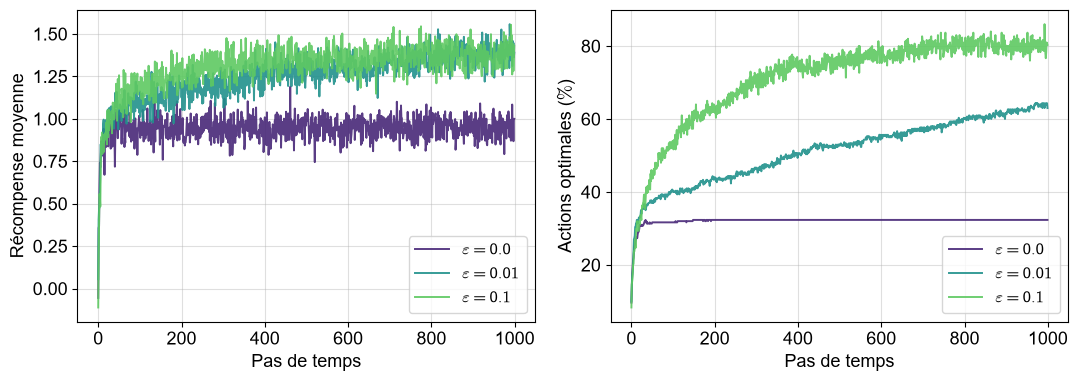

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

for (eps, (r, o)), coul in zip(resultats.items(), [VIOLET, SARCELLE, VERT]):
    ax1.plot(r, color=coul, linewidth=1.4, alpha=0.9, label=f"$\\varepsilon = {eps}$")
    ax2.plot(100 * o, color=coul, linewidth=1.4, alpha=0.9, label=f"$\\varepsilon = {eps}$")
ax1.set_xlabel("Pas de temps")
ax1.set_ylabel("Récompense moyenne")
ax2.set_xlabel("Pas de temps")
ax2.set_ylabel(f"Actions optimales ($\\%$)")
for ax in (ax1, ax2):
    ax.grid(alpha=0.4, zorder=0)
    ax.legend(fontsize=12, loc='lower right')

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap15_Bandit')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 15.3 : Le monde en grille</h3>

In [7]:
class MondeGrille:
    """Grille 3 x 4. But +1 en (0,3), piège -1 en (1,3), mur en (1,1),
    départ en (2,0). L'action voulue aboutit avec la probabilité p_succes
    et dévie à angle droit sinon."""

    ACTIONS = ['haut', 'bas', 'gauche', 'droite']
    PAS = {'haut': (-1, 0), 'bas': (1, 0), 'gauche': (0, -1), 'droite': (0, 1)}
    PERP = {'haut': ['gauche', 'droite'], 'bas': ['gauche', 'droite'],
            'gauche': ['haut', 'bas'], 'droite': ['haut', 'bas']}

    def __init__(self, recompense_pas=-0.04, p_succes=0.8):
        self.n_lignes, self.n_colonnes = 3, 4
        self.mur = {(1, 1)}
        self.terminaux = {(0, 3): 1.0, (1, 3): -1.0}
        self.depart = (2, 0)
        self.recompense_pas = recompense_pas
        self.p_succes = p_succes
        self.etats = [(i, j) for i in range(3) for j in range(4)
                      if (i, j) not in self.mur]

    def deplacement(self, s, direction):
        di, dj = self.PAS[direction]
        s2 = (s[0] + di, s[1] + dj)
        hors = not (0 <= s2[0] < self.n_lignes and 0 <= s2[1] < self.n_colonnes)
        return s if hors or s2 in self.mur else s2

    def transitions(self, s, a):
        """Liste de (probabilité, état suivant, récompense, terminal)."""
        if s in self.terminaux:
            return []
        p_lat = (1 - self.p_succes) / 2
        sortie = []
        for d, p in [(a, self.p_succes)] + [(x, p_lat) for x in self.PERP[a]]:
            s2 = self.deplacement(s, d)
            sortie.append((p, s2, self.terminaux.get(s2, self.recompense_pas),
                           s2 in self.terminaux))
        return sortie

env = MondeGrille()

# --- Affichage ---
etat = (2, 0)
action = 'haut'

L = 60

print("=" * L)
print(f"Transitions depuis {etat} - action « {action} » ({FLECHE[action]})")
print("=" * L)
print(f"{'Probabilité':>12}{'État suivant':>16}"
      f"{'Récompense':>16}{'Terminal':>16}")
print("-" * L)

for p, s2, r, terminal in env.transitions(etat, action):
    print(f"{p:>12.1f}{str(s2):>16}"
          f"{r:>+16.2f}{str(terminal):>16}")

print("=" * L)
print(f"États non terminaux : {len(env.etats) - len(env.terminaux)}")

Transitions depuis (2, 0) - action « haut » (↑)
 Probabilité    État suivant      Récompense        Terminal
------------------------------------------------------------
         0.8          (1, 0)           -0.04           False
         0.1          (2, 0)           -0.04           False
         0.1          (2, 1)           -0.04           False
États non terminaux : 9


<h3><span style="font-size: 30px">&#127924;</span> Figure : Le monde en grille</h3>

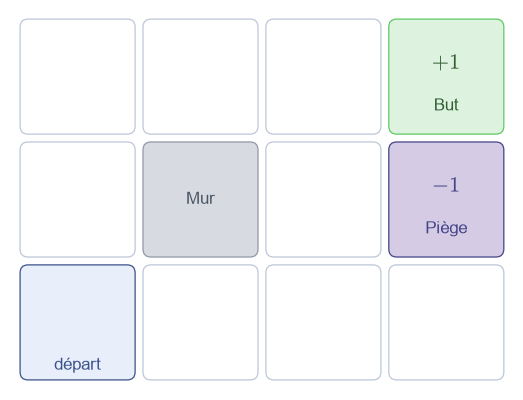

In [8]:
fig, ax = plt.subplots(figsize=(5.5, 4.2))

dessiner_grille(ax, env)
fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap15_Grille')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 15.4 : Évaluation itérative d'une politique</h3>

In [9]:
def evaluation_politique(env, pi, gamma=1.0, seuil=1e-6):
    """Applique l'équation de Bellman d'évaluation jusqu'à convergence."""
    V = {s: 0.0 for s in env.etats}
    balayages = 0
    while True:
        delta = 0.0
        for s in env.etats:
            if s in env.terminaux:
                continue
            v = V[s]
            V[s] = sum(pi[s][a] * sum(p * (r + gamma * (0.0 if t else V[s2]))
                                      for p, s2, r, t in env.transitions(s, a))
                       for a in env.ACTIONS)
            delta = max(delta, abs(v - V[s]))
        balayages += 1
        if delta < seuil:
            return V, balayages

# Politique aléatoire uniforme
pi_alea = {s: {a: 0.25 for a in env.ACTIONS}
           for s in env.etats if s not in env.terminaux}

V_alea, n_balayages = evaluation_politique(env, pi_alea)
print(f"Convergence en {n_balayages} balayages")
print(f"Valeur de l'état de départ : {V_alea[env.depart]:.3f}")

Convergence en 223 balayages
Valeur de l'état de départ : -1.547


<h3><span style="font-size: 30px">&#127924;</span> Figure : Évaluation de la politique aléatoire</h3>

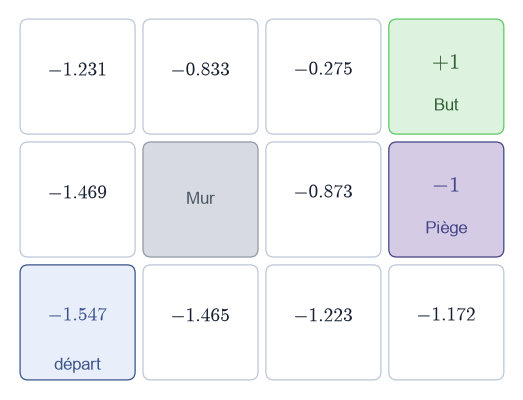

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 4.2))

dessiner_grille(ax, env, valeurs=V_alea)
fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap15_Evaluation')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 15.5 : Itération sur les politiques</h3>

In [11]:
def action_gloutonne(env, V, s, gamma=1.0):
    """Action maximisant l'espérance de récompense immédiate plus valeur suivante."""
    return max(env.ACTIONS, key=lambda a: sum(
        p * (r + gamma * (0.0 if t else V[s2]))
        for p, s2, r, t in env.transitions(s, a)))

def iteration_politiques(env, gamma=1.0, seuil=1e-6):
    """Alterne évaluation complète et amélioration jusqu'à stabilité."""
    pi = {s: {a: (1.0 if a == 'haut' else 0.0) for a in env.ACTIONS}
          for s in env.etats if s not in env.terminaux}
    iterations, balayages = 0, 0
    while True:
        V, nb = evaluation_politique(env, pi, gamma, seuil)
        balayages += nb
        iterations += 1
        stable = True
        for s in pi:
            ancienne = max(pi[s], key=pi[s].get)
            meilleure = action_gloutonne(env, V, s, gamma)
            if meilleure != ancienne:
                stable = False
            pi[s] = {a: (1.0 if a == meilleure else 0.0) for a in env.ACTIONS}
        if stable:
            return V, pi, iterations, balayages

V_pi, pi_pi, n_iter, n_bal = iteration_politiques(env)
print(f"{n_iter} itérations de politique, {n_bal} balayages au total")
print(f"Valeur optimale de l'état de départ : {V_pi[env.depart]:.3f}")

5 itérations de politique, 548 balayages au total
Valeur optimale de l'état de départ : 0.745


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 15.6 : Itération sur les valeurs</h3>

In [12]:
def iteration_valeurs(env, gamma=1.0, seuil=1e-6):
    """Fusionne évaluation et amélioration en une seule mise à jour."""
    V = {s: 0.0 for s in env.etats}
    balayages, ecarts = 0, []
    while True:
        delta = 0.0
        for s in env.etats:
            if s in env.terminaux:
                continue
            v = V[s]
            V[s] = max(sum(p * (r + gamma * (0.0 if t else V[s2]))
                           for p, s2, r, t in env.transitions(s, a))
                       for a in env.ACTIONS)
            delta = max(delta, abs(v - V[s]))
        balayages += 1
        ecarts.append(delta)
        if delta < seuil:
            pi = {s: action_gloutonne(env, V, s, gamma)
                  for s in env.etats if s not in env.terminaux}
            return V, pi, balayages, ecarts

V_opt, pi_opt, n_bal_v, ecarts = iteration_valeurs(env)
print(f"Convergence en {n_bal_v} balayages")
print(f"Écart maximal avec l'itération sur les politiques : "
      f"{max(abs(V_opt[s] - V_pi[s]) for s in env.etats):.2e}")
print("Politiques identiques :",
      all(max(pi_pi[s], key=pi_pi[s].get) == pi_opt[s] for s in pi_opt))

Convergence en 19 balayages
Écart maximal avec l'itération sur les politiques : 1.04e-08
Politiques identiques : True


<h3><span style="font-size: 30px">&#127924;</span> Figure : Politique et valeurs optimales</h3>

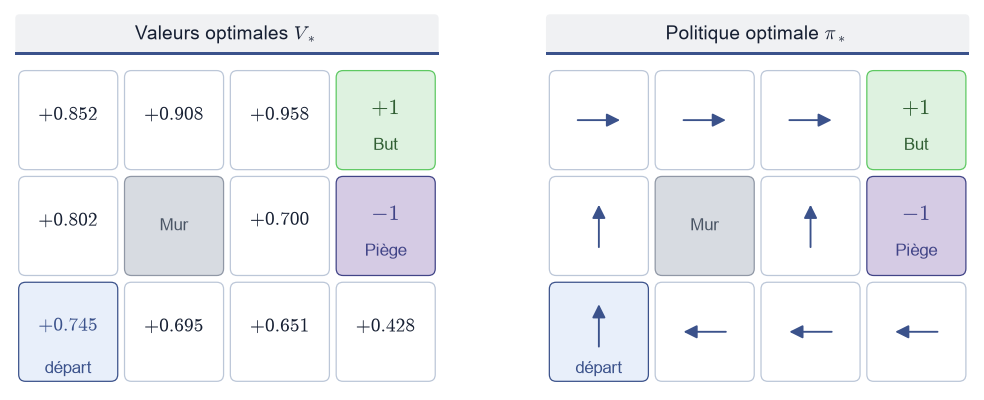

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

dessiner_grille(ax1, env, valeurs=V_opt, titre="Valeurs optimales $V_*$")
dessiner_grille(ax2, env, politique=pi_opt, titre="Politique optimale $\\pi_*$")
fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap15_PolitiqueOptimale')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 15.7 : Génération d'un épisode</h3>

In [14]:
def episode(env, pi, rng, depart=None, action0=None, max_pas=500):
    """Déroule un épisode sous la politique pi et renvoie la liste (s, a, r)."""
    s = env.depart if depart is None else depart
    traj, premier = [], True
    for _ in range(max_pas):
        if premier and action0 is not None:
            a, premier = action0, False
        else:
            a = rng.choice(env.ACTIONS, p=[pi[s][x] for x in env.ACTIONS])
        transitions = env.transitions(s, a)
        i = rng.choice(len(transitions), p=[p for p, *_ in transitions])
        _, s2, r, fin = transitions[i]
        traj.append((s, a, r))
        s = s2
        if fin:
            return traj
    raise RuntimeError(f"Épisode non terminé après {max_pas} pas.")

rng = np.random.default_rng(42)
traj = episode(env, pi_alea, rng)
retour = sum(r for _, _, r in traj)

# --- Affichage ---
L = 48

print("=" * L)
print("Premiers pas de l'épisode")
print("=" * L)
print(f"{'Pas':>6}{'État':>14}{'Action':>12}{'Récompense':>16}")
print("-" * L)

for pas, (s, a, r) in enumerate(traj[:5], start=1):
    print(f"{pas:>6}{str(s):>14}{FLECHE[a]:>12}{r:>+16.2f}")

if len(traj) > 5:
    print(f"{'...':^{L}}")

print("=" * L)
print(f"Épisode terminé : {len(traj)} pas  |  retour = {retour:+.2f}")


Premiers pas de l'épisode
   Pas          État      Action      Récompense
------------------------------------------------
     1        (2, 0)           →           -0.04
     2        (2, 1)           →           -0.04
     3        (2, 2)           ↑           -0.04
     4        (2, 3)           →           -0.04
     5        (2, 3)           ↑           -1.00
Épisode terminé : 5 pas  |  retour = -1.16


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 15.8 : Monte-Carlo à premier passage</h3>

In [15]:
def mc_premier_passage(env, pi, n_episodes, gamma=1.0, graine=42, reference=None):
    """Moyenne des retours observés au premier passage dans chaque état."""
    rng = np.random.default_rng(graine)
    somme = {s: 0.0 for s in env.etats}
    compte = {s: 0 for s in env.etats}
    courbe = []
    for k in range(1, n_episodes + 1):
        traj = episode(env, pi, rng)
        gains, G = [0.0] * len(traj), 0.0
        for t in range(len(traj) - 1, -1, -1):
            G = traj[t][2] + gamma * G
            gains[t] = G
        premiers = {}
        for t, (s, a, r) in enumerate(traj):
            premiers.setdefault(s, t)
        for s, t in premiers.items():
            somme[s] += gains[t]
            compte[s] += 1
        if reference is not None and k % 25 == 0:
            V = {s: (somme[s] / compte[s] if compte[s] else 0.0) for s in env.etats}
            courbe.append((k, max(abs(V[s] - reference[s]) for s in env.etats
                                  if s not in env.terminaux)))
    V = {s: (somme[s] / compte[s] if compte[s] else 0.0) for s in env.etats}
    return V, courbe

n_episodes_mc = 5000
V_mc, courbe = mc_premier_passage(env, pi_alea, n_episodes_mc, reference=V_alea)
valeur_mc = V_mc[env.depart]
valeur_dp = V_alea[env.depart]
ecart_max = max(
    abs(V_mc[s] - V_alea[s])
    for s in env.etats
    if s not in env.terminaux
)

# --- Affichage ---
L = 62
print("=" * L)
print(f"Évaluation MC à premier passage ({n_episodes_mc} épisodes)")
print("=" * L)
print(f"{'Valeur MC (départ)':>21}{'Valeur DP (départ)':>21}{'Écart maximal':>20}")
print("-" * L)
print(f"{valeur_mc:>21.3f}{valeur_dp:>21.3f}{ecart_max:>20.3f}")
print("=" * L)

Évaluation MC à premier passage (5000 épisodes)
   Valeur MC (départ)   Valeur DP (départ)       Écart maximal
--------------------------------------------------------------
               -1.550               -1.547               0.030


<h3><span style="font-size: 30px">&#127924;</span> Figure : Convergence de l'évaluation Monte-Carlo</h3>

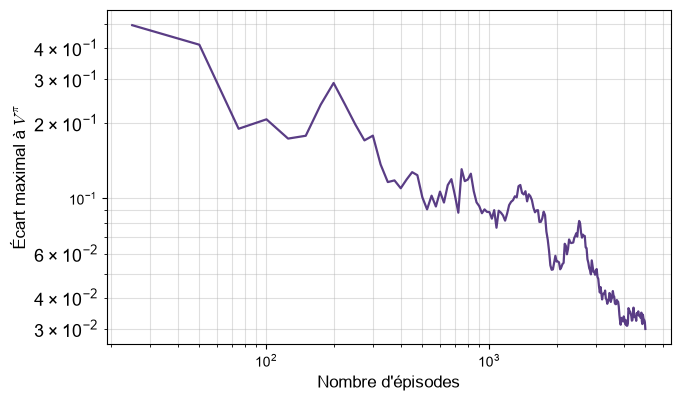

In [16]:
k, err = zip(*courbe)

fig, ax = plt.subplots(figsize=(7, 4.2))

ax.plot(k, err, color=VIOLET, linewidth=1.6, alpha=0.9, zorder=3)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel("Nombre d'épisodes", fontsize=12)
ax.set_ylabel("Écart maximal à $V^\\pi$", fontsize=12)
ax.grid(alpha=0.4, which='both', zorder=0)
ax.tick_params(labelsize=10)
fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap15_ConvergenceMC')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 15.9 : Contrôle Monte-Carlo $\varepsilon$-glouton</h3>

In [17]:
def politique_eps_gloutonne(Q, actions, epsilon):
    """Politique epsilon-gloutonne dérivée des valeurs d'action."""
    pi = {}
    for s in Q:
        meilleure = max(Q[s], key=Q[s].get)
        pi[s] = {a: (1 - epsilon + epsilon / len(actions) if a == meilleure
                     else epsilon / len(actions)) for a in actions}
    return pi

def controle_mc(env, n_episodes, epsilon=0.1, gamma=1.0, graine=42,
                departs_exploratoires=False):
    """Contrôle Monte-Carlo à premier passage sur les couples état-action."""
    rng = np.random.default_rng(graine)
    Q = {s: {a: 0.0 for a in env.ACTIONS}
         for s in env.etats if s not in env.terminaux}
    N = {s: {a: 0 for a in env.ACTIONS} for s in Q}
    etats = list(Q)
    for _ in range(n_episodes):
        pi = politique_eps_gloutonne(Q, env.ACTIONS, epsilon)
        if departs_exploratoires:
            s0 = etats[rng.integers(len(etats))]
            a0 = env.ACTIONS[rng.integers(len(env.ACTIONS))]
            traj = episode(env, pi, rng, depart=s0, action0=a0)
        else:
            traj = episode(env, pi, rng)
        gains, G = [0.0] * len(traj), 0.0
        for t in range(len(traj) - 1, -1, -1):
            G = traj[t][2] + gamma * G
            gains[t] = G
        premiers = {}
        for t, (s, a, r) in enumerate(traj):
            premiers.setdefault((s, a), t)
        for (s, a), t in premiers.items():
            N[s][a] += 1
            Q[s][a] += (gains[t] - Q[s][a]) / N[s][a]
    return Q, N, {s: max(Q[s], key=Q[s].get) for s in Q}

Q_mc, N_mc, pi_mc = controle_mc(env, 20000)
identiques = sum(pi_mc[s] == pi_opt[s] for s in pi_opt)
desaccords = [s for s in pi_opt if pi_mc[s] != pi_opt[s]]

# --- Affichage ---
L = 48
print("=" * L)
print("Désaccords avec la politique optimale")
print("=" * L)
print(f"{'État':>12}{'Action MC':>18}{'Action optimale':>18}")
print("-" * L)

for s in desaccords:
    print(f"{str(s):>12}"
          f"{FLECHE[pi_mc[s]]:>18}"
          f"{FLECHE[pi_opt[s]]:>18}")

print("=" * L)
print(f"Actions identiques : {identiques} / {len(pi_opt)}")

Désaccords avec la politique optimale
        État         Action MC   Action optimale
------------------------------------------------
      (2, 1)                 →                 ←
      (2, 2)                 ↑                 ←
Actions identiques : 7 / 9


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 15.10 : Départs exploratoires</h3>

In [18]:
def moins_visite(N):
    """Renvoie le couple état-action le moins visité."""
    return min((N[s][a], s, a) for s in N for a in N[s])

# Contrôle Monte-Carlo avec départs exploratoires
Q_es, N_es, pi_es = controle_mc(env, 20000, departs_exploratoires=True)

# Comparaison avec la politique optimale
identiques_es = sum(pi_es[s] == pi_opt[s] for s in pi_opt)
total_actions = len(pi_opt)

# Couples état-action les moins visités
n_fixe, etat_fixe, action_fixe = moins_visite(N_mc)
n_explo, etat_explo, action_explo = moins_visite(N_es)

visites_minimales = [
    ("Départ fixe", n_fixe, etat_fixe, action_fixe),
    ("Départs exploratoires", n_explo, etat_explo, action_explo)
]

# --- Affichage ---
L = 62
print("=" * L)
print("Couples état-action les moins visités")
print("=" * L)
print(f"{'Protocole':<24}{'État':>14}{'Action':>12}{'Visites':>12}")
print("-" * L)

for nom, n, s, a in visites_minimales:
    print(f"{nom:<24}{str(s):>14}{FLECHE[a]:>12}{n:>12}")

print("=" * L)
print(f"Actions identiques (départs exploratoires) : {identiques_es} / {total_actions}")

Couples état-action les moins visités
Protocole                         État      Action     Visites
--------------------------------------------------------------
Départ fixe                     (2, 3)           →          20
Départs exploratoires           (2, 3)           →         577
Actions identiques (départs exploratoires) : 9 / 9


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 15.11 : Évaluation hors politique par échantillonnage préférentiel</h3>

In [19]:
def mc_hors_politique(env, pi_cible, pi_comport, n_episodes, gamma=1.0, graine=42):
    """Échantillonnage préférentiel pondéré : estime V pour pi_cible
    à partir d'épisodes engendrés par pi_comport."""
    rng = np.random.default_rng(graine)
    numerateur = {s: 0.0 for s in env.etats}
    denominateur = {s: 0.0 for s in env.etats}
    for _ in range(n_episodes):
        traj = episode(env, pi_comport, rng)
        G, W = 0.0, 1.0
        for t in range(len(traj) - 1, -1, -1):
            s, a, r = traj[t]
            G = r + gamma * G
            W *= pi_cible[s][a] / pi_comport[s][a]
            if W == 0.0:
                break
            numerateur[s] += W * G
            denominateur[s] += W
    return {s: (numerateur[s] / denominateur[s] if denominateur[s] > 0 else 0.0)
            for s in env.etats}

# La politique cible est la politique optimale, la politique de comportement est aléatoire
pi_cible = {s: {a: (1.0 if a == pi_opt[s] else 0.0) for a in env.ACTIONS}
            for s in pi_opt}
V_hp = mc_hors_politique(env, pi_cible, pi_alea, 20000)

print(f"Valeur estimée hors politique de l'état de départ : {V_hp[env.depart]:.3f}")
print(f"Valeur exacte de la politique cible               : {V_opt[env.depart]:.3f}")

Valeur estimée hors politique de l'état de départ : 0.796
Valeur exacte de la politique cible               : 0.745


<h3><span style="font-size: 30px">&#127924;</span> Figure : Trois politiques obtenues par trois voies</h3>

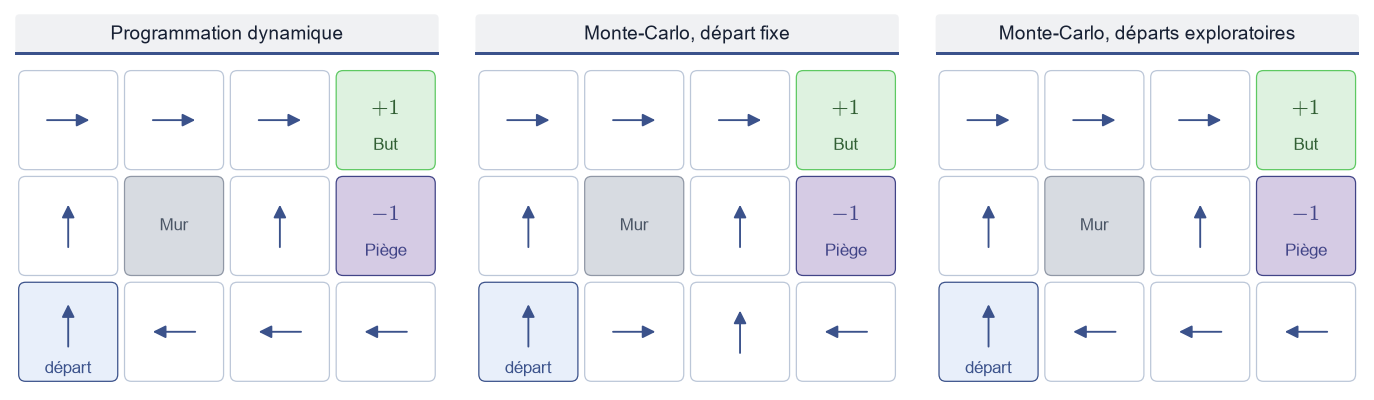

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

dessiner_grille(axes[0], env, politique=pi_opt, 
                titre="Programmation dynamique")

dessiner_grille(axes[1], env, politique=pi_mc,
                titre="Monte-Carlo, départ fixe")

dessiner_grille(axes[2], env, politique=pi_es,
                titre="Monte-Carlo, départs exploratoires")

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap15_ComparaisonDPMC')

plt.show()

<hr style='border-top:4px solid #1F77B4;'>